In [15]:
import pickle
import re
import sys
from pathlib import Path

import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import scanpy as sc
import seaborn as sns
from scipy.stats import norm

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.core.calibration import bh_fdr_reject

ZDIR = Path('./Z_scores_mixed')
PCDIR = config.PATHWAY_CONV_DIR
PFDIR = config.PATHWAY_CONV_FIG_DIR
PCDIR.mkdir(parents=True, exist_ok=True)
PFDIR.mkdir(parents=True, exist_ok=True)
PP = config.PATHWAY_CONV_PARAMS

PHENOTYPE = 'Pancreatic Cancer'
PDIR = PCDIR / PHENOTYPE.replace(' ', '_')
PDIR.mkdir(parents=True, exist_ok=True)

In [16]:
# 0. Load cohort (reuse 3_disease_scoring.ipynb cache)
Z = np.load(ZDIR / 'Z_disease_shash.npy')
gene_names = pickle.load(open(ZDIR / 'gene_names.pkl', 'rb'))
meta = pd.read_csv(ZDIR / 'sample_meta.csv')

cohort_mask = (meta['phenotype'] == PHENOTYPE) & meta['ood_keep']
idx = np.where(cohort_mask.values)[0]
names_c = meta['sample'].values[idx]
Zc = Z[idx]
n_pat = len(idx)

print(f"{PHENOTYPE}: {n_pat} patients (OOD-kept), {len(gene_names)} genes")

Pancreatic Cancer: 72 patients (OOD-kept), 19858 genes


In [17]:
def pairwise_overlap(masks):
    # Jaccard + overlap-coefficient for every patient pair, given a (n_patients, n_items) bool matrix
    inter = masks.astype(int) @ masks.astype(int).T
    sizes = masks.sum(axis=1)
    union = sizes[:, None] + sizes[None, :] - inter
    jacc = np.divide(inter, union, out=np.zeros_like(inter, dtype=float), where=union > 0)
    minsz = np.minimum(sizes[:, None], sizes[None, :])
    ovc = np.divide(inter, minsz, out=np.zeros_like(inter, dtype=float), where=minsz > 0)
    iu = np.triu_indices(masks.shape[0], k=1)
    return jacc[iu], ovc[iu]


# 1. Gene-level deviation: per-patient BH-FDR significant genes (ENSG resolution)
p_all = 2 * norm.sf(np.abs(Zc))
gene_sig = np.zeros_like(p_all, dtype=bool)
for i in range(n_pat):
    row = p_all[i]
    finite = np.isfinite(row)
    reject = np.zeros(len(row), dtype=bool)
    if finite.any():
        reject[finite] = bh_fdr_reject(row[finite], q=PP['fdr_q'])
    gene_sig[i] = reject

n_gene_sig = gene_sig.sum(axis=1)
gene_jacc, gene_ovc = pairwise_overlap(gene_sig)

print(f"BH-sig genes/patient: min={n_gene_sig.min()} median={np.median(n_gene_sig):.0f} max={n_gene_sig.max()}")
print(f"GENE-level pairwise Jaccard: mean={gene_jacc.mean():.4f} median={np.median(gene_jacc):.4f}")

BH-sig genes/patient: min=0 median=10 max=351
GENE-level pairwise Jaccard: mean=0.0023 median=0.0000


-1

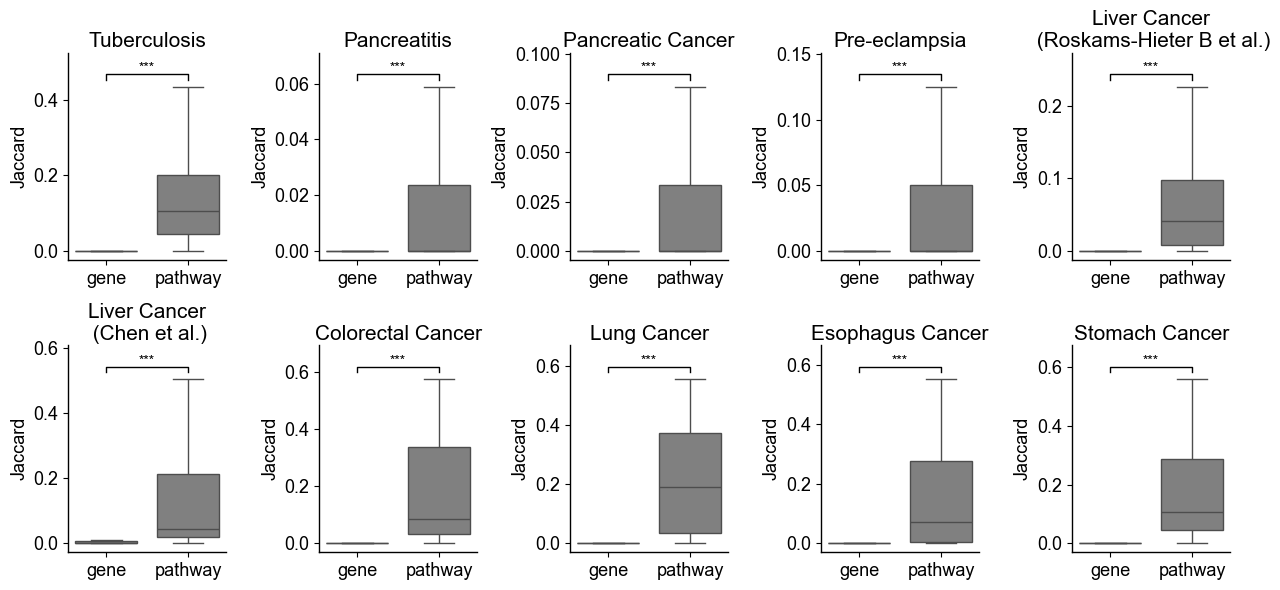

level                                    gene  pathway    ratio
phenotype                                                      
Tuberculosis                           0.0009   0.1340 153.3480
Pancreatitis                           0.0014   0.0273  19.8416
Pancreatic Cancer                      0.0023   0.0347  15.1067
Pre-eclampsia                          0.0010   0.0345  35.5946
Liver Cancer (Roskams-Hieter B et al.) 0.0014   0.0652  47.3991
Liver Cancer (Chen et al.)             0.0094   0.1245  13.2084
Colorectal Cancer                      0.0011   0.1698 155.0196
Lung Cancer                            0.0021   0.2046  96.8577
Esophagus Cancer                       0.0013   0.1494 117.3267
Stomach Cancer                         0.0024   0.1717  71.8050


In [28]:
from scipy.stats import wilcoxon

from MixedEffectsModeling.core.pathway_convergence import slugify

# ME/CFS dropped -- literature review found only one weakly-supported pathway. Liver Cancer split
# into its 2 constituent studies (Roskams-Hieter B n=28, Chen n=10) instead of pooled -- pooling
# blended 3 different studies' technical variance (Block et al. n=2 dropped entirely, too small)
ALL_PHENOTYPES = ['Tuberculosis', 'Pancreatitis', 'Pancreatic Cancer', 'Pre-eclampsia',
                  'Liver Cancer (Roskams-Hieter B et al.)', 'Liver Cancer (Chen et al.)',
                  'Colorectal Cancer', 'Lung Cancer', 'Esophagus Cancer', 'Stomach Cancer']

def sig_stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'

def whisker_top(vals, whis=1.5):
    q1, q3 = np.percentile(vals, [25, 75])
    upper = q3 + whis * (q3 - q1)
    within = vals[vals <= upper]
    return within.max() if len(within) else q3


jacc_rows = []
for ph in ALL_PHENOTYPES:
    sig_path = PCDIR / slugify(ph) / 'sig.pkl'
    if not sig_path.exists():
        continue
    d = pickle.load(open(sig_path, 'rb'))
    gj, _ = pairwise_overlap(d['gene_sig'])
    pj, _ = pairwise_overlap(d['path_sig'])
    jacc_rows += [(ph, 'gene', v) for v in gj] + [(ph, 'pathway', v) for v in pj]
jacc_df = pd.DataFrame(jacc_rows, columns=['phenotype', 'level', 'Jaccard'])

ncols = 5
nrows = int(np.ceil(len(ALL_PHENOTYPES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 3 * nrows),sharey=False)
for ax, ph in zip(axes.flat, ALL_PHENOTYPES):
    sub = jacc_df[jacc_df['phenotype'] == ph]
    if sub.empty:
        ax.set_visible(False)
        continue
    sns.boxplot(data=sub, x='level', y='Jaccard', ax=ax, showfliers=False, color='gray', width=0.75)
    if ph.find('Liver') == -1 :
        ax.set_title(ph, pad=4)
    else: 
        ax.set_title(ph.split('Cancer')[0] + 'Cancer' + '\n' + ph.split('Cancer')[1], pad=4)
    ax.set_xlabel('')

    gv = sub.loc[sub['level'] == 'gene', 'Jaccard'].values
    pv = sub.loc[sub['level'] == 'pathway', 'Jaccard'].values
    stat_p = wilcoxon(pv, gv, zero_method='wilcox').pvalue  # paired -- same patient-pair index in both

    y0 = max(whisker_top(gv), whisker_top(pv))
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    y0 += 0.04 * y_range
    h = 0.03 * y_range
    ax.plot([0, 0, 1, 1], [y0, y0 + h, y0 + h, y0], lw=1, c='black')
    ax.text(0.5, y0 + h, sig_stars(stat_p), ha='center', va='bottom')
    ax.set_ylim(top=y0 + h + 0.12 * y_range)
for ax in axes.flat[len(ALL_PHENOTYPES):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(PFDIR / 'all_phenotypes_gene_vs_pathway_jaccard.png', dpi=150)
plt.show()

summary = jacc_df.groupby(['phenotype', 'level'])['Jaccard'].mean().unstack()
summary['ratio'] = summary['pathway'] / summary['gene']
print(summary.reindex(ALL_PHENOTYPES).to_string(float_format=lambda v: f'{v:.4f}'))

In [29]:
# 2. Gene set library + collapse Z to gene-symbol universe (pathways are defined by symbol, ENSG has
# a handful of duplicate-symbol entries that must be merged before matrix-multiplying against a pathway
# membership matrix)
UNIV_PATH = PCDIR / 'universe.pkl'
if UNIV_PATH.exists():
    universe_syms, sym2idx, Zu, Fm = pickle.load(open(UNIV_PATH, 'rb'))
else:
    sym_of = sc.read_h5ad(config.H5AD_PATH, backed='r').var['GeneName'].reindex(gene_names)
    syms_all = sym_of.values
    universe_syms = pd.unique(syms_all[sym_of.notna().values])
    sym2idx = {s: i for i, s in enumerate(universe_syms)}
    N = len(universe_syms)
    col2sym = np.array([sym2idx.get(s, -1) if pd.notna(s) else -1 for s in syms_all])
    keep_cols = col2sym >= 0
    Zc_v, sym_idx_v = Zc[:, keep_cols], col2sym[keep_cols]

    sum_mat, finite_cnt = np.zeros((n_pat, N)), np.zeros((n_pat, N))
    for i in range(n_pat):
        np.add.at(sum_mat[i], sym_idx_v, np.nan_to_num(Zc_v[i], nan=0.0))
        np.add.at(finite_cnt[i], sym_idx_v, np.isfinite(Zc_v[i]).astype(float))
    Zu_raw = np.divide(sum_mat, finite_cnt, out=np.full_like(sum_mat, np.nan), where=finite_cnt > 0)
    Zu = np.nan_to_num(Zu_raw, nan=0.0)
    Fm = np.isfinite(Zu_raw).astype(float)
    pickle.dump((universe_syms, sym2idx, Zu, Fm), open(UNIV_PATH, 'wb'))

N = len(universe_syms)

LIB_PATH = PCDIR / 'gene_set_matrix.pkl'
if LIB_PATH.exists():
    terms_raw, M_raw = pickle.load(open(LIB_PATH, 'rb'))
else:
    libs = {}
    for lib in PP['gene_sets']:
        libs.update(gp.get_library(lib, organism='human'))
    terms_raw = list(libs.keys())
    M_raw = np.zeros((len(terms_raw), N), dtype=bool)
    for ti, t in enumerate(terms_raw):
        for g in libs[t]:
            j = sym2idx.get(g)
            if j is not None:
                M_raw[ti, j] = True
    keep = M_raw.sum(axis=1) >= PP['min_pathway_size']
    terms_raw, M_raw = [t for t, k in zip(terms_raw, keep) if k], M_raw[keep]
    pickle.dump((terms_raw, M_raw), open(LIB_PATH, 'wb'))

# housekeeping exclusion: composition-based (share of a pathway's own genes that are ribosomal-protein
# genes, using KEGG "Ribosome" as reference) catches translation-dominated pathways regardless of name
# -- Influenza Infection, SLIT/ROBO signaling, Cellular Response To Starvation were all >45% ribosomal
# by gene composition despite unrelated names. Plus a name-keyword pass for OXPHOS/neurodegeneration.
ribo_idx = np.where(M_raw[terms_raw.index(PP['ribo_reference_term'])])[0]
frac_ribo = M_raw[:, ribo_idx].sum(axis=1) / M_raw.sum(axis=1)
kw_rx = re.compile('|'.join(PP['exclude_keywords']), re.IGNORECASE)
keep_hk = (frac_ribo <= PP['ribo_frac_max']) & np.array([not kw_rx.search(t) for t in terms_raw])
terms, M = [t for t, k in zip(terms_raw, keep_hk) if k], M_raw[keep_hk]

print(f"universe: {N} gene symbols, {len(terms)} pathways after housekeeping exclusion "
      f"({(~keep_hk).sum()} dropped of {len(terms_raw)})")

universe: 19831 gene symbols, 2063 pathways after housekeeping exclusion (68 dropped of 2131)


In [30]:
# 3. Per-patient/per-pathway mean-Z + per-patient permutation null (K=200, ~2min) -- cache-first
NULL_PATH = PDIR / 'null.npz'
Mf = M.astype(float)

if NULL_PATH.exists():
    d = np.load(NULL_PATH)
    T, null_mean, null_sd = d['T'], d['null_mean'], d['null_sd']
else:
    num, den = (Zu * Fm) @ Mf.T, Fm @ Mf.T
    T = np.divide(num, den, out=np.zeros_like(num), where=den > 0)

    rng = np.random.default_rng(PP['seed'])
    null_sum, null_sumsq = np.zeros_like(T), np.zeros_like(T)
    for _ in range(PP['n_null_perm']):
        perm = rng.permutation(N)
        Zp, Fp = Zu[:, perm], Fm[:, perm]
        nu, de = (Zp * Fp) @ Mf.T, Fp @ Mf.T
        Tn = np.divide(nu, de, out=np.zeros_like(nu), where=de > 0)
        null_sum += Tn
        null_sumsq += Tn ** 2
    null_mean = null_sum / PP['n_null_perm']
    null_sd = np.sqrt(np.clip(null_sumsq / PP['n_null_perm'] - null_mean ** 2, 1e-12, None))
    np.savez(NULL_PATH, T=T, null_mean=null_mean, null_sd=null_sd)

Tz = (T - null_mean) / null_sd
p_path = 2 * norm.sf(np.abs(Tz))
path_sig = np.zeros_like(p_path, dtype=bool)
for i in range(n_pat):
    path_sig[i] = bh_fdr_reject(p_path[i], q=PP['fdr_q'])

n_path_sig = path_sig.sum(axis=1)
path_jacc, path_ovc = pairwise_overlap(path_sig)

print(f"sig pathways/patient: min={n_path_sig.min()} median={np.median(n_path_sig):.0f} max={n_path_sig.max()}  "
      f"(zero: {(n_path_sig == 0).sum()}/{n_pat})")
print(f"PATHWAY-level pairwise Jaccard: mean={path_jacc.mean():.4f} median={np.median(path_jacc):.4f}")
print(f"ratio vs gene-level mean Jaccard: {path_jacc.mean() / gene_jacc.mean():.1f}x")

sig pathways/patient: min=0 median=12 max=354  (zero: 10/72)
PATHWAY-level pairwise Jaccard: mean=0.0347 median=0.0000
ratio vs gene-level mean Jaccard: 15.1x


In [32]:
import cairosvg
from MixedEffectsModeling.core.pathway_convergence import (
    load_pathway_library, load_symbol_vocab, match_pathway_index, parse_selected_pathways,
    slugify, strip_reactome_code,
)

PCDIR = config.PATHWAY_CONV_DIR
PFDIR = config.PATHWAY_CONV_FIG_DIR
PFDIR.mkdir(parents=True, exist_ok=True)

# ME/CFS dropped -- literature review found only one weakly-supported pathway. Liver Cancer split
# into its 2 constituent studies instead of pooled (see run_pathway_convergence_batch.py) -- each
# gets its own Sankey since pooling blended 3 different studies' technical variance
PHENOTYPES = [
    'Tuberculosis', 'Pancreatitis', 'Pancreatic Cancer', 'Pre-eclampsia',
    'Liver Cancer (Roskams-Hieter B et al.)', 'Liver Cancer (Chen et al.)',
    'Colorectal Cancer', 'Lung Cancer', 'Esophagus Cancer', 'Stomach Cancer',
]

# only Pancreatic Cancer has a severity/subtype column in this cohort (see 4_gene_enrichment.ipynb
# sec. 7) -- everyone else gets a single neutral patient color
SEVERITY_COL = 'Stage/Condition'
SEVERITY_COLORS = {'PDAC': '#d55e00', 'IPMN': '#0072b2', 'Islet Cell Tumor': '#009e73'}
DEFAULT_PATIENT_COLOR = "#737373"

EDGE_Z_MIN = 1.75
MAX_GENES_PER_PATHWAY = 15
HISTONE_FAMILY_CAP = 2
histone_rx = re.compile(r'^(H1|H2A|H2B|H3|H4)')


def gene_family(sym):
    m = histone_rx.match(sym)
    return m.group(1) if m else sym


def hex_to_rgba(hex_str, a):
    r, g, b = (int(hex_str.lstrip('#')[k:k + 2], 16) for k in (0, 2, 4))
    return f'rgba({r},{g},{b},{a})'


def build_sankey(phenotype, universe_syms, terms, M):
    slug = slugify(phenotype)
    pdir = PCDIR / slug
    review_path = pdir / 'pathway_literature_review.md'
    if not review_path.exists():
        print(f'{phenotype}: no literature review found, skipping')
        return

    names = parse_selected_pathways(review_path)
    top_idx, missing = [], []
    for name in names:
        j = match_pathway_index(name, terms)
        (top_idx if j is not None else missing).append(j if j is not None else name)
    if missing:
        print(f'{phenotype}: could not match {missing} to a pathway term, skipping those')
    if not top_idx:
        print(f'{phenotype}: no matched pathways, skipping')
        return

    d = pickle.load(open(pdir / 'sig.pkl', 'rb'))
    path_sig, Tz = d['path_sig'], d['Tz']
    Zu, Fm = pickle.load(open(pdir / 'universe.pkl', 'rb'))
    n_pat = path_sig.shape[0]

    if phenotype == 'Pancreatic Cancer':
        names_c = d['names_c']
        severity = sc.read_h5ad(config.H5AD_PATH, backed='r').obs[SEVERITY_COL].reindex(names_c).values
        pat_color = lambda i: SEVERITY_COLORS.get(severity[i], '#999999')
    else:
        pat_color = lambda i: DEFAULT_PATIENT_COLOR

    PATH_COLORS = [f'#{"".join(f"{int(c * 255):02x}" for c in plt.get_cmap("tab10")(k)[:3])}'
                   for k in range(len(top_idx))]

    pathway_gene_edges = {pi: {} for pi in range(len(top_idx))}
    for pi, j in enumerate(top_idx):
        members = np.where(M[j])[0]
        pats = np.where(path_sig[:, j])[0]
        if len(pats) == 0 or len(members) == 0:
            continue
        sub = Zu[np.ix_(pats, members)]
        qual = np.abs(sub) >= EDGE_Z_MIN
        gcols_all = np.where(qual.any(axis=0))[0]
        if len(gcols_all) == 0:
            continue
        deg = qual[:, gcols_all].sum(axis=0)
        strength = np.where(qual[:, gcols_all], np.abs(sub[:, gcols_all]), 0).sum(axis=0)
        ranked = gcols_all[np.lexsort((-strength, -deg))]
        gcols, family_count = [], {}
        for gc in ranked:
            fam = gene_family(universe_syms[members[gc]])
            if family_count.get(fam, 0) >= HISTONE_FAMILY_CAP:
                continue
            gcols.append(gc)
            family_count[fam] = family_count.get(fam, 0) + 1
            if len(gcols) == MAX_GENES_PER_PATHWAY:
                break
        for gc in gcols:
            gu = members[gc]
            pathway_gene_edges[pi][gu] = {pats[k]: sub[k, gc] for k in range(len(pats)) if abs(sub[k, gc]) >= EDGE_Z_MIN}

    gene_strength = {}
    for pi, edges_by_gene in pathway_gene_edges.items():
        for gu, edges in edges_by_gene.items():
            gene_strength.setdefault(gu, {})[pi] = sum(abs(z) for z in edges.values())
    if not gene_strength:
        print(f'{phenotype}: no gene edges survived EDGE_Z_MIN, skipping')
        return
    gene_primary_pi = {gu: max(dd, key=dd.get) for gu, dd in gene_strength.items()}
    displayed_genes = sorted(gene_strength,
                             key=lambda gu: (gene_primary_pi[gu], -gene_strength[gu][gene_primary_pi[gu]]))

    pat_gene_z = {}
    for edges_by_gene in pathway_gene_edges.values():
        for gu, edges in edges_by_gene.items():
            for i, z in edges.items():
                pat_gene_z[(i, gu)] = abs(z)
    displayed_pats = sorted({i for i, _ in pat_gene_z})

    n_pat_d, n_gene_d, n_path_d = len(displayed_pats), len(displayed_genes), len(top_idx)
    pat_pos = {i: k for k, i in enumerate(displayed_pats)}
    gene_pos = {gu: k for k, gu in enumerate(displayed_genes)}

    node_labels = ([f'patient {i}' for i in displayed_pats] + [universe_syms[gu] for gu in displayed_genes]
                  + [strip_reactome_code(terms[j]) for j in top_idx])
    node_colors = ([pat_color(i) for i in displayed_pats]
                  + [PATH_COLORS[gene_primary_pi[gu]] for gu in displayed_genes]
                  + PATH_COLORS)

    src, tgt, val, link_col = [], [], [], []
    for (i, gu), z in pat_gene_z.items():
        src.append(pat_pos[i])
        tgt.append(n_pat_d + gene_pos[gu])
        val.append(z)
        link_col.append(hex_to_rgba(pat_color(i), 0.35))
    for pi, edges_by_gene in pathway_gene_edges.items():
        for gu, edges in edges_by_gene.items():
            src.append(n_pat_d + gene_pos[gu])
            tgt.append(n_pat_d + n_gene_d + pi)
            val.append(sum(abs(z) for z in edges.values()))
            link_col.append(hex_to_rgba(PATH_COLORS[pi], 0.45))

    fig = go.Figure(go.Sankey(
        arrangement='snap',
        node=dict(label=node_labels, color=node_colors, pad=3, thickness=10, line=dict(width=0)),
        link=dict(source=src, target=tgt, value=val, color=link_col),
    ))
    fig.update_layout(width=1000, height=max(900, (n_pat_d + n_gene_d) * 12), font_size=11, title=f'{phenotype} pathway convergence')

    # plotly.js hardcodes a white text-shadow halo on Sankey node labels -- strip it via SVG post-process
    svg = fig.to_image(format='svg').decode('utf-8')
    svg = re.sub(r'text-shadow:[^;"]*;', '', svg)
    out_path = PFDIR / f'{slug}_pathway_convergence_sankey.png'
    cairosvg.svg2png(bytestring=svg.encode('utf-8'), write_to=str(out_path), scale=2)
    print(f'{phenotype}: {n_pat_d} patients, {n_gene_d} genes, {n_path_d} pathways -> {out_path}')


if __name__ == '__main__':
    universe_syms, sym2idx, _ = load_symbol_vocab(None)
    terms, M = load_pathway_library()
    for ph in PHENOTYPES:
        build_sankey(ph, universe_syms, terms, M)


/tmp/ipykernel_91783/915718684.py:152: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')


Tuberculosis: 91 patients, 75 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Tuberculosis_pathway_convergence_sankey.png
Pancreatitis: 33 patients, 93 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Pancreatitis_pathway_convergence_sankey.png


/tmp/ipykernel_91783/915718684.py:152: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  svg = fig.to_image(format='svg').decode('utf-8')


Pancreatic Cancer: 36 patients, 90 genes, 8 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Pancreatic_Cancer_pathway_convergence_sankey.png
Pre-eclampsia: 32 patients, 113 genes, 8 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Pre-eclampsia_pathway_convergence_sankey.png
Liver Cancer (Roskams-Hieter B et al.): 25 patients, 90 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Liver_Cancer_(Roskams-Hieter_B_et_al.)_pathway_convergence_sankey.png
Liver Cancer (Chen et al.): 8 patients, 97 genes, 7 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Liver_Cancer_(Chen_et_al.)_pathway_convergence_sankey.png
Colorectal Cancer: 23 patients, 23 genes, 8 pathways -> /project/cfRNA_NormativeModeling/MixedEffectsModeling/PathwayConvergence/Figures/Colorectal_Cancer_pathway_convergence_sankey.png
Lung Cancer: 19 pa